# Black Friday purchases

This notebook is the analysis from start to finish. Read the short note above each block, run the code, then read the observation under the output.

1. Inspect each purchase row.
2. Check missing values and duplicate rows.
3. Plot the distributions.
4. Switch to one row per customer and compute 90% confidence intervals.
5. See which product categories carry the spend, and separate purchase counts from spend per customer.
6. Try to predict a customer's total spend from who they are.
7. Try to predict one purchase once the product category is known.

A purchase row and a customer are different units. Several early counts look large only because that group has more rows.


## 1. Inspect each purchase

Load the file and look at the table before any grouping. The goal is to see what one row is, which columns exist, and how `Purchase` is shaped.

`Stay_In_Current_City_Years` is stored with a `+` on the longest stay (`4+`). That symbol is removed and the column is converted to a number so later numeric summaries can use it.


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.stats import norm
import warnings

sns.set(color_codes=True)
warnings.filterwarnings("ignore")

walmart_df =  pd.read_csv("Data/walmart_data.csv")
walmart_df

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969
...,...,...,...,...,...,...,...,...,...,...
550063,1006033,P00372445,M,51-55,13,B,1,1,20,368
550064,1006035,P00375436,F,26-35,1,C,3,0,20,371
550065,1006036,P00375436,F,26-35,15,B,4+,1,20,137
550066,1006038,P00375436,F,55+,1,C,2,0,20,365


In [ ]:
#Here, we'll first look at the Walmart dataset. We'll check the first and last few rows to understand what the data looks like.
walmart_df.head()

In [5]:
#Here, we'll first look at the Walmart dataset. We'll check the first and last few rows to understand what the data looks like.
walmart_df.tail()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
550063,1006033,P00372445,M,51-55,13,B,1,1,20,368
550064,1006035,P00375436,F,26-35,1,C,3,0,20,371
550065,1006036,P00375436,F,26-35,15,B,4+,1,20,137
550066,1006038,P00375436,F,55+,1,C,2,0,20,365
550067,1006039,P00371644,F,46-50,0,B,4+,1,20,490


In [8]:
print("\n Shape of the dataframe")
walmart_df.shape


 Shape of the dataframe


(550068, 10)

In [9]:
print("\n Name of each column in dataframe")
walmart_df.columns


 Name of each column in dataframe


Index(['User_ID', 'Product_ID', 'Gender', 'Age', 'Occupation', 'City_Category',
       'Stay_In_Current_City_Years', 'Marital_Status', 'Product_Category',
       'Purchase'],
      dtype='str')

In [10]:
print("\n datatype of each column")
walmart_df.dtypes


 datatype of each column


User_ID                       int64
Product_ID                      str
Gender                          str
Age                             str
Occupation                    int64
City_Category                   str
Stay_In_Current_City_Years      str
Marital_Status                int64
Product_Category              int64
Purchase                      int64
dtype: object

In [11]:
#We will find out the unique values in each columns. This will help us understand how varied the data is

def print_unique_values(df):
    for column in df.columns:
        unique_values = df[column].unique()
        print(f"\nUnique Values of {column}: ", unique_values)

print_unique_values(walmart_df)


Unique Values of User_ID:  [1000001 1000002 1000003 ... 1004113 1005391 1001529]

Unique Values of Product_ID:  <ArrowStringArray>
['P00069042', 'P00248942', 'P00087842', 'P00085442', 'P00285442', 'P00193542',
 'P00184942', 'P00346142',  'P0097242', 'P00274942',
 ...
 'P00295642', 'P00091742', 'P00350742', 'P00060842', 'P00057842', 'P00375436',
 'P00372445', 'P00370293', 'P00371644', 'P00370853']
Length: 3631, dtype: str

Unique Values of Gender:  <ArrowStringArray>
['F', 'M']
Length: 2, dtype: str

Unique Values of Age:  <ArrowStringArray>
['0-17', '55+', '26-35', '46-50', '51-55', '36-45', '18-25']
Length: 7, dtype: str

Unique Values of Occupation:  [10 16 15  7 20  9  1 12 17  0  3  4 11  8 19  2 18  5 14 13  6]

Unique Values of City_Category:  <ArrowStringArray>
['A', 'C', 'B']
Length: 3, dtype: str

Unique Values of Stay_In_Current_City_Years:  <ArrowStringArray>
['2', '4+', '3', '1', '0']
Length: 5, dtype: str

Unique Values of Marital_Status:  [0 1]

Unique Values of Product_

In [12]:
#Check how many unique values there are in each column

def print_nunique_values(df):
    for column in df.columns:
        unique_values = df[column].nunique()
        print(f"\nQty of unique values of {column}: ",unique_values)

print_nunique_values(walmart_df)


Qty of unique values of User_ID:  5891

Qty of unique values of Product_ID:  3631

Qty of unique values of Gender:  2

Qty of unique values of Age:  7

Qty of unique values of Occupation:  21

Qty of unique values of City_Category:  3

Qty of unique values of Stay_In_Current_City_Years:  5

Qty of unique values of Marital_Status:  2

Qty of unique values of Product_Category:  20

Qty of unique values of Purchase:  18105


In [13]:
#We will adjust the stays_in_current_city_years by removing the '+' and converting it to a numeric format
walmart_df.Stay_In_Current_City_Years.unique()

<ArrowStringArray>
['2', '4+', '3', '1', '0']
Length: 5, dtype: str

In [14]:
#Removing '+'

walmart_df.Stay_In_Current_City_Years = walmart_df.Stay_In_Current_City_Years.str.replace("+","")

In [15]:
walmart_df['Stay_In_Current_City_Years'] = pd.to_numeric(walmart_df['Stay_In_Current_City_Years'])

In [16]:
#Here we will look some statistics of the data
# mean, sd, min, max.
# It will give a good idea of the overall distrubution and rage of the data
# We need to select all data that are numerical

walmart_df.select_dtypes(include = ['int64']).skew()

User_ID                       0.003066
Occupation                    0.400140
Stay_In_Current_City_Years    0.317236
Marital_Status                0.367437
Product_Category              1.025735
Purchase                      0.600140
dtype: float64

In [17]:
walmart_df.describe(include = 'all')

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
count,5.500680e+05,550068,550068,550068,550068.000000,550068,550068.000000,550068.000000,550068.000000,550068.000000
unique,NaN,3631,2,7,NaN,3,NaN,NaN,NaN,NaN
top,NaN,P00265242,M,26-35,NaN,B,NaN,NaN,NaN,NaN
freq,NaN,1880,414259,219587,NaN,231173,NaN,NaN,NaN,NaN
mean,1.003029e+06,NaN,NaN,NaN,8.076707,NaN,1.858418,0.409653,5.404270,9263.968713
std,1.727592e+03,NaN,NaN,NaN,6.522660,NaN,1.289443,0.491770,3.936211,5023.065394
min,1.000001e+06,NaN,NaN,NaN,0.000000,NaN,0.000000,0.000000,1.000000,12.000000
25%,1.001516e+06,NaN,NaN,NaN,2.000000,NaN,1.000000,0.000000,1.000000,5823.000000
50%,1.003077e+06,NaN,NaN,NaN,7.000000,NaN,2.000000,0.000000,5.000000,8047.000000
75%,1.004478e+06,NaN,NaN,NaN,14.000000,NaN,3.000000,1.000000,8.000000,12054.000000


### Observation

The table has 550,068 purchase rows and 10 columns. There are 5,891 distinct customers (`User_ID`).

`Purchase` runs from $12 to $23,961. The mean sits above the median, so the distribution has a long right tail. A few large purchases pull the average up.

Men, age 26–35, and city B have the most purchase rows. Those numbers are counts of rows. They are not yet spend per customer. That comparison comes after the data are collapsed to one row per `User_ID`.


## 2. Check missing values and duplicates

Missing values and repeated rows would distort counts, means, and intervals. This step counts both before any chart or model.


In [18]:
#MISSING VALUE DETECTION
# We will check if there are any missing value in the data.
#Missing Values can affect the analysis, so its important to know if there are any

walmart_df.isna().sum()

User_ID                       0
Product_ID                    0
Gender                        0
Age                           0
Occupation                    0
City_Category                 0
Stay_In_Current_City_Years    0
Marital_Status                0
Product_Category              0
Purchase                      0
dtype: int64

In [19]:
#Duplication
# We will also look for any duplicate entries in the data. Duplicates can skew our analysis

walmart_df.duplicated(subset=None,keep='first').sum()

np.int64(0)

### Observation

Every column has 0 missing values. The duplicate count is 0. The later averages and intervals are not being pulled by empty cells or repeated rows.


## 3. Plot the distributions

Histograms show occupation, years in the current city, marital status, and purchase amount. The purchase panel also draws a normal curve with the same mean and standard deviation, to see whether that shape fits.

The bar charts count purchases in each level of gender, age, occupation, city, years in the city, marital status, and product category. The last panel is a histogram of `Purchase`.


In [20]:
# DATA VISUALIZATION
# First lets do for our numerical values

walmart_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 10 columns):
 #   Column                      Non-Null Count   Dtype
---  ------                      --------------   -----
 0   User_ID                     550068 non-null  int64
 1   Product_ID                  550068 non-null  str  
 2   Gender                      550068 non-null  str  
 3   Age                         550068 non-null  str  
 4   Occupation                  550068 non-null  int64
 5   City_Category               550068 non-null  str  
 6   Stay_In_Current_City_Years  550068 non-null  int64
 7   Marital_Status              550068 non-null  int64
 8   Product_Category            550068 non-null  int64
 9   Purchase                    550068 non-null  int64
dtypes: int64(6), str(4)
memory usage: 50.3 MB


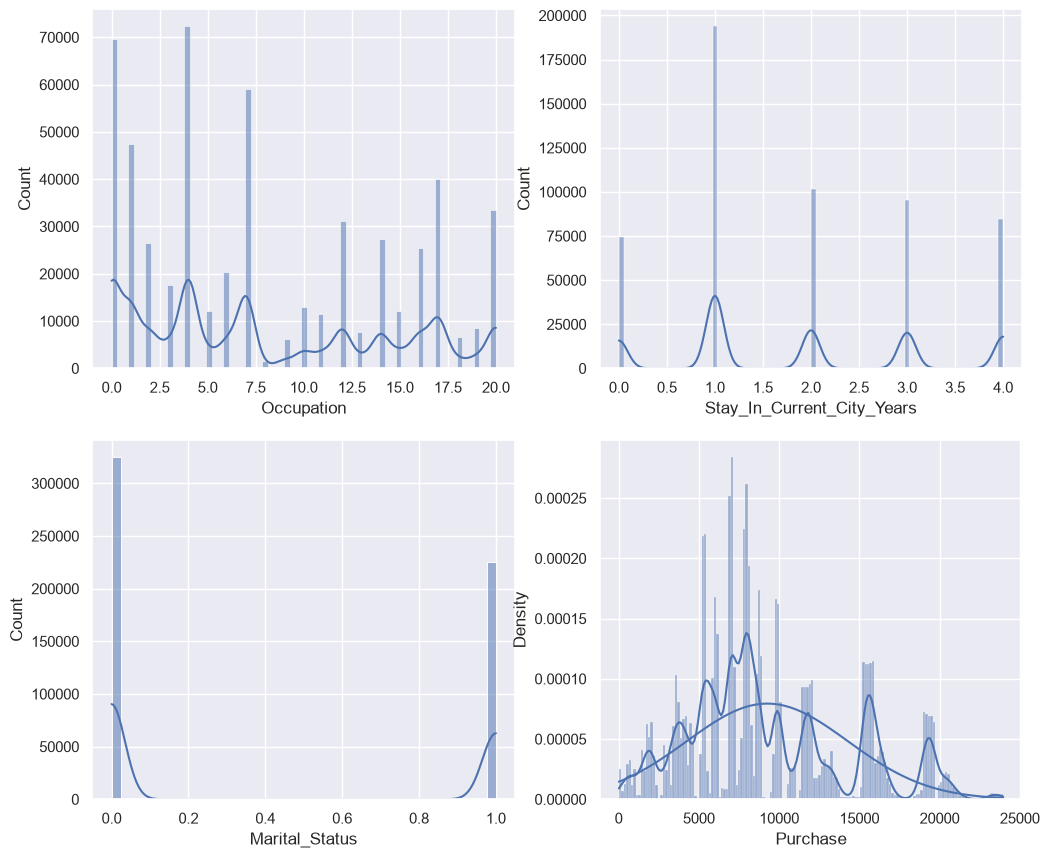

In [21]:
# Variables: occupation, stay_in_current_city_years, marital_status, purchase

# Create a 2x2 grid of subplots
fig,axis = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))
fig.subplots_adjust(top=0.9) #adjust the top spacing of the subplots

# plot distrubution plots for each specified column
# use sns.histplot()
# Parameters

# data= → qual DataFrame usar
# x= → qual coluna colocar no eixo X
# bins= → quantas barras/intervalos criar
# kde=True → adiciona a curva suave de distribuição
# color= → define a cor
# hue= → separa o gráfico por uma categoria
# stat= → define o que o eixo Y representa
# multiple= → controla como grupos aparecem quando há hue
# ax= → diz em qual subplot desenhar

sns.histplot(
    data = walmart_df,
    x = walmart_df['Occupation'],
    kde = True,
    ax =axis[0,0] #onde o grafico vai ficar de acordo com o 2x2 grid of subplots
)
sns.histplot(
    data = walmart_df,
    x = walmart_df['Stay_In_Current_City_Years'],
    kde = True,
    ax =axis[0,1] #onde o grafico vai ficar de acordo com o 2x2 grid of subplots
)
sns.histplot(
    data = walmart_df,
    x = walmart_df['Marital_Status'],
    kde = True,
    ax =axis[1,0] #onde o grafico vai ficar de acordo com o 2x2 grid of subplots
)

ax = axis[1,1]
sns.histplot(
    data = walmart_df,
    x = walmart_df['Purchase'],
    kde = True,
    ax = ax, #onde o grafico vai ficar de acordo com o 2x2 grid of subplots
    stat= 'density' #queremos adicionar uma normal distribution
)

#1. descobrir qual normal combina com os dados (preciso do mean e do sd)
mu, sigma = norm.fit(walmart_df['Purchase'])

#2. criar 100 pontos no eixo x
x = np.linspace(
    walmart_df['Purchase'].min(),
    walmart_df['Purchase'].max(),
    100
)

#3. calcular a altura da normal em cada ponto - pra cada x, qual sera o y?
y = norm.pdf(x,mu,sigma)

ax.plot(x,y)

In [26]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

df = pd.read_csv("Data/walmart_data.csv")

categorical_columns = [
    "Gender",
    "Age",
    "Occupation",
    "City_Category",
    "Stay_In_Current_City_Years",
    "Marital_Status",
    "Product_Category",
]

numerical_columns = [
    "Purchase",
]

all_columns = categorical_columns + numerical_columns

eda_fig = make_subplots(
    rows=4,
    cols=2,
    subplot_titles=all_columns,
)

for plot_index, column_name in enumerate(all_columns):
    subplot_row = plot_index // 2 + 1
    subplot_col = plot_index % 2 + 1

    if column_name in categorical_columns:
        category_counts = df[column_name].value_counts().sort_index()

        eda_fig.add_trace(
            go.Bar(
                x=category_counts.index.astype(str),
                y=category_counts.values,
                name=column_name,
            ),
            row=subplot_row,
            col=subplot_col,
        )
    else:
        eda_fig.add_trace(
            go.Histogram(
                x=df[column_name],
                name=column_name,
                nbinsx=30,
            ),
            row=subplot_row,
            col=subplot_col,
        )

eda_fig.update_layout(
    height=1200,
    width=1000,
    title_text="Walmart Feature Distributions",
    showlegend=False,
)

eda_fig.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

### Observation

Occupation, years in the city, and marital status take a few discrete values, so those histograms are spikes, not smooth bells.

`Purchase` is right-skewed. The normal curve does not follow the histogram: most purchases sit left of the mean, with a long tail to the right.

The bar charts repeat the row counts from the summary table. Men, age 26–35, and city B contribute the most purchases. Product category is uneven. A tall bar means more rows, not a higher spend per person.


## 4. Confidence intervals for one customer

From here, each row is one customer. `Purchase` is that customer's total spend, the sum of their purchase rows.

The interval is 90%. The margin is `1.64 * standard deviation / sqrt(n)`. `1.64` is the normal value that leaves 5% of the probability in each tail. The same four lines are repeated for each group. Only the group changes.

A positive gap means the first interval starts after the second interval ends, so they do not overlap. A negative gap means the two intervals cross.


In [ ]:
# uma linha por cliente homem; Purchase é a soma das compras dele
male_df = walmart_df[walmart_df["Gender"] == "M"].groupby("User_ID")["Purchase"].sum().reset_index()
# uma linha por cliente mulher; Purchase é a soma das compras dela
female_df = walmart_df[walmart_df["Gender"] == "F"].groupby("User_ID")["Purchase"].sum().reset_index()
# uma linha por cliente da cidade A
city_a_df = walmart_df[walmart_df["City_Category"] == "A"].groupby("User_ID")["Purchase"].sum().reset_index()
# uma linha por cliente da cidade B
city_b_df = walmart_df[walmart_df["City_Category"] == "B"].groupby("User_ID")["Purchase"].sum().reset_index()
# uma linha por cliente da cidade C
city_c_df = walmart_df[walmart_df["City_Category"] == "C"].groupby("User_ID")["Purchase"].sum().reset_index()
# uma linha por cliente de 0 a 17 anos
age_0_17_df = walmart_df[walmart_df["Age"] == "0-17"].groupby("User_ID")["Purchase"].sum().reset_index()
# uma linha por cliente de 18 a 25 anos
age_18_25_df = walmart_df[walmart_df["Age"] == "18-25"].groupby("User_ID")["Purchase"].sum().reset_index()
# uma linha por cliente de 26 a 35 anos
age_26_35_df = walmart_df[walmart_df["Age"] == "26-35"].groupby("User_ID")["Purchase"].sum().reset_index()
# uma linha por cliente de 36 a 45 anos
age_36_45_df = walmart_df[walmart_df["Age"] == "36-45"].groupby("User_ID")["Purchase"].sum().reset_index()
# uma linha por cliente de 46 a 50 anos
age_46_50_df = walmart_df[walmart_df["Age"] == "46-50"].groupby("User_ID")["Purchase"].sum().reset_index()
# uma linha por cliente de 51 a 55 anos
age_51_55_df = walmart_df[walmart_df["Age"] == "51-55"].groupby("User_ID")["Purchase"].sum().reset_index()
# uma linha por cliente de 55 anos ou mais
age_55_plus_df = walmart_df[walmart_df["Age"] == "55+"].groupby("User_ID")["Purchase"].sum().reset_index()
# uma linha por cliente solteiro (Marital_Status 0)
marital_0_df = walmart_df[walmart_df["Marital_Status"] == 0].groupby("User_ID")["Purchase"].sum().reset_index()
# uma linha por cliente casado (Marital_Status 1)
marital_1_df = walmart_df[walmart_df["Marital_Status"] == 1].groupby("User_ID")["Purchase"].sum().reset_index()


### City

Same 90% interval, for customers in city A, city B, and city C.


In [ ]:
# margem de erro de 90%: 1.64 vezes o desvio padrão, dividido pela raiz da quantidade de clientes
city_a_margin_of_error_clt = 1.64*city_a_df['Purchase'].std()/np.sqrt(len(city_a_df))
# média de Purchase desse grupo
city_a_sample_mean = city_a_df['Purchase'].mean()
# limite de baixo: média menos a margem
city_a_lower_lim = city_a_sample_mean - city_a_margin_of_error_clt
# limite de cima: média mais a margem
city_a_upper_lim = city_a_sample_mean + city_a_margin_of_error_clt
# mostra o intervalo com 2 casas decimais
print("City A confidence interval of means: ({:.2f}, {:.2f})".format(city_a_lower_lim, city_a_upper_lim))

# margem de erro de 90%: 1.64 vezes o desvio padrão, dividido pela raiz da quantidade de clientes
city_b_margin_of_error_clt = 1.64*city_b_df['Purchase'].std()/np.sqrt(len(city_b_df))
# média de Purchase desse grupo
city_b_sample_mean = city_b_df['Purchase'].mean()
# limite de baixo: média menos a margem
city_b_lower_lim = city_b_sample_mean - city_b_margin_of_error_clt
# limite de cima: média mais a margem
city_b_upper_lim = city_b_sample_mean + city_b_margin_of_error_clt
# mostra o intervalo com 2 casas decimais
print("City B confidence interval of means: ({:.2f}, {:.2f})".format(city_b_lower_lim, city_b_upper_lim))

# margem de erro de 90%: 1.64 vezes o desvio padrão, dividido pela raiz da quantidade de clientes
city_c_margin_of_error_clt = 1.64*city_c_df['Purchase'].std()/np.sqrt(len(city_c_df))
# média de Purchase desse grupo
city_c_sample_mean = city_c_df['Purchase'].mean()
# limite de baixo: média menos a margem
city_c_lower_lim = city_c_sample_mean - city_c_margin_of_error_clt
# limite de cima: média mais a margem
city_c_upper_lim = city_c_sample_mean + city_c_margin_of_error_clt
# mostra o intervalo com 2 casas decimais
print("City C confidence interval of means: ({:.2f}, {:.2f})".format(city_c_lower_lim, city_c_upper_lim))

# limite de baixo de A menos limite de cima de C; positivo significa que A começa depois que C termina
gap_between_city_a_and_c = city_a_lower_lim - city_c_upper_lim
# limite de baixo de B menos limite de cima de C
gap_between_city_b_and_c = city_b_lower_lim - city_c_upper_lim
# limite de baixo de A menos limite de cima de B; negativo significa que as duas faixas se cruzam
gap_between_city_a_and_b = city_a_lower_lim - city_b_upper_lim
# mostra a separação entre A e C
print("Gap between city A and city C intervals: {:.2f}".format(gap_between_city_a_and_c))
# mostra a separação entre B e C
print("Gap between city B and city C intervals: {:.2f}".format(gap_between_city_b_and_c))
# mostra a separação entre A e B
print("Gap between city A and city B intervals: {:.2f}".format(gap_between_city_a_and_b))


### Observation

City A is about $1,189,977 to $1,329,586. City B is about $1,197,030 to $1,281,627. City C is about $517,493 to $542,595.

The gaps from A to C and from B to C are positive, about $647,000 and $654,000. City C sits entirely below A and B. The gap from A to B is negative, about $-92,000, so A and B overlap.

At customer level, C is a large group of much smaller totals. A single purchase in C can still look a bit larger. The customer total is lower because each C customer contributes less spend overall.


### Age

Same 90% interval for each age band. The gaps subtract each other band's upper limit from the lower limit of age 26–35.


In [ ]:
# margem de erro de 90%: 1.64 vezes o desvio padrão, dividido pela raiz da quantidade de clientes
age_0_17_margin_of_error_clt = 1.64*age_0_17_df['Purchase'].std()/np.sqrt(len(age_0_17_df))
# média de Purchase desse grupo
age_0_17_sample_mean = age_0_17_df['Purchase'].mean()
# limite de baixo: média menos a margem
age_0_17_lower_lim = age_0_17_sample_mean - age_0_17_margin_of_error_clt
# limite de cima: média mais a margem
age_0_17_upper_lim = age_0_17_sample_mean + age_0_17_margin_of_error_clt
# mostra o intervalo com 2 casas decimais
print("Age 0-17 confidence interval of means: ({:.2f}, {:.2f})".format(age_0_17_lower_lim, age_0_17_upper_lim))

# margem de erro de 90%: 1.64 vezes o desvio padrão, dividido pela raiz da quantidade de clientes
age_18_25_margin_of_error_clt = 1.64*age_18_25_df['Purchase'].std()/np.sqrt(len(age_18_25_df))
# média de Purchase desse grupo
age_18_25_sample_mean = age_18_25_df['Purchase'].mean()
# limite de baixo: média menos a margem
age_18_25_lower_lim = age_18_25_sample_mean - age_18_25_margin_of_error_clt
# limite de cima: média mais a margem
age_18_25_upper_lim = age_18_25_sample_mean + age_18_25_margin_of_error_clt
# mostra o intervalo com 2 casas decimais
print("Age 18-25 confidence interval of means: ({:.2f}, {:.2f})".format(age_18_25_lower_lim, age_18_25_upper_lim))

# margem de erro de 90%: 1.64 vezes o desvio padrão, dividido pela raiz da quantidade de clientes
age_26_35_margin_of_error_clt = 1.64*age_26_35_df['Purchase'].std()/np.sqrt(len(age_26_35_df))
# média de Purchase desse grupo
age_26_35_sample_mean = age_26_35_df['Purchase'].mean()
# limite de baixo: média menos a margem
age_26_35_lower_lim = age_26_35_sample_mean - age_26_35_margin_of_error_clt
# limite de cima: média mais a margem
age_26_35_upper_lim = age_26_35_sample_mean + age_26_35_margin_of_error_clt
# mostra o intervalo com 2 casas decimais
print("Age 26-35 confidence interval of means: ({:.2f}, {:.2f})".format(age_26_35_lower_lim, age_26_35_upper_lim))

# margem de erro de 90%: 1.64 vezes o desvio padrão, dividido pela raiz da quantidade de clientes
age_36_45_margin_of_error_clt = 1.64*age_36_45_df['Purchase'].std()/np.sqrt(len(age_36_45_df))
# média de Purchase desse grupo
age_36_45_sample_mean = age_36_45_df['Purchase'].mean()
# limite de baixo: média menos a margem
age_36_45_lower_lim = age_36_45_sample_mean - age_36_45_margin_of_error_clt
# limite de cima: média mais a margem
age_36_45_upper_lim = age_36_45_sample_mean + age_36_45_margin_of_error_clt
# mostra o intervalo com 2 casas decimais
print("Age 36-45 confidence interval of means: ({:.2f}, {:.2f})".format(age_36_45_lower_lim, age_36_45_upper_lim))

# margem de erro de 90%: 1.64 vezes o desvio padrão, dividido pela raiz da quantidade de clientes
age_46_50_margin_of_error_clt = 1.64*age_46_50_df['Purchase'].std()/np.sqrt(len(age_46_50_df))
# média de Purchase desse grupo
age_46_50_sample_mean = age_46_50_df['Purchase'].mean()
# limite de baixo: média menos a margem
age_46_50_lower_lim = age_46_50_sample_mean - age_46_50_margin_of_error_clt
# limite de cima: média mais a margem
age_46_50_upper_lim = age_46_50_sample_mean + age_46_50_margin_of_error_clt
# mostra o intervalo com 2 casas decimais
print("Age 46-50 confidence interval of means: ({:.2f}, {:.2f})".format(age_46_50_lower_lim, age_46_50_upper_lim))

# margem de erro de 90%: 1.64 vezes o desvio padrão, dividido pela raiz da quantidade de clientes
age_51_55_margin_of_error_clt = 1.64*age_51_55_df['Purchase'].std()/np.sqrt(len(age_51_55_df))
# média de Purchase desse grupo
age_51_55_sample_mean = age_51_55_df['Purchase'].mean()
# limite de baixo: média menos a margem
age_51_55_lower_lim = age_51_55_sample_mean - age_51_55_margin_of_error_clt
# limite de cima: média mais a margem
age_51_55_upper_lim = age_51_55_sample_mean + age_51_55_margin_of_error_clt
# mostra o intervalo com 2 casas decimais
print("Age 51-55 confidence interval of means: ({:.2f}, {:.2f})".format(age_51_55_lower_lim, age_51_55_upper_lim))

# margem de erro de 90%: 1.64 vezes o desvio padrão, dividido pela raiz da quantidade de clientes
age_55_plus_margin_of_error_clt = 1.64*age_55_plus_df['Purchase'].std()/np.sqrt(len(age_55_plus_df))
# média de Purchase desse grupo
age_55_plus_sample_mean = age_55_plus_df['Purchase'].mean()
# limite de baixo: média menos a margem
age_55_plus_lower_lim = age_55_plus_sample_mean - age_55_plus_margin_of_error_clt
# limite de cima: média mais a margem
age_55_plus_upper_lim = age_55_plus_sample_mean + age_55_plus_margin_of_error_clt
# mostra o intervalo com 2 casas decimais
print("Age 55+ confidence interval of means: ({:.2f}, {:.2f})".format(age_55_plus_lower_lim, age_55_plus_upper_lim))

# limite de baixo de 26-35 menos o limite de cima de 0-17
gap_26_35_and_0_17 = age_26_35_lower_lim - age_0_17_upper_lim
# limite de baixo de 26-35 menos o limite de cima de 18-25
gap_26_35_and_18_25 = age_26_35_lower_lim - age_18_25_upper_lim
# limite de baixo de 26-35 menos o limite de cima de 36-45
gap_26_35_and_36_45 = age_26_35_lower_lim - age_36_45_upper_lim
# limite de baixo de 26-35 menos o limite de cima de 46-50
gap_26_35_and_46_50 = age_26_35_lower_lim - age_46_50_upper_lim
# limite de baixo de 26-35 menos o limite de cima de 51-55
gap_26_35_and_51_55 = age_26_35_lower_lim - age_51_55_upper_lim
# limite de baixo de 26-35 menos o limite de cima de 55+
gap_26_35_and_55_plus = age_26_35_lower_lim - age_55_plus_upper_lim
# positivo significa que 26-35 começa depois que 0-17 termina
print("Gap 26-35 minus 0-17: {:.2f}".format(gap_26_35_and_0_17))
# positivo significa que 26-35 começa depois que 18-25 termina
print("Gap 26-35 minus 18-25: {:.2f}".format(gap_26_35_and_18_25))
# positivo significa que 26-35 começa depois que 36-45 termina
print("Gap 26-35 minus 36-45: {:.2f}".format(gap_26_35_and_36_45))
# positivo significa que 26-35 começa depois que 46-50 termina
print("Gap 26-35 minus 46-50: {:.2f}".format(gap_26_35_and_46_50))
# positivo significa que 26-35 começa depois que 51-55 termina
print("Gap 26-35 minus 51-55: {:.2f}".format(gap_26_35_and_51_55))
# positivo significa que 26-35 começa depois que 55+ termina
print("Gap 26-35 minus 55+: {:.2f}".format(gap_26_35_and_55_plus))


### Observation

Age 26–35 is about $952,320 to $1,026,999. Every printed gap is positive, so this band sits above 0–17, 18–25, 36–45, 46–50, 51–55, and 55+.

The widest gap is versus 55+ (about $360,000). The narrowest is versus 36–45 (about $26,000), and it is still positive. Age 36–45 is not in the same tier as 26–35.


### Marital status

Same 90% interval for unmarried customers (`Marital_Status` 0) and married customers (`Marital_Status` 1).


In [ ]:
# margem de erro de 90%: 1.64 vezes o desvio padrão, dividido pela raiz da quantidade de clientes
marital_0_margin_of_error_clt = 1.64*marital_0_df['Purchase'].std()/np.sqrt(len(marital_0_df))
# média de Purchase desse grupo
marital_0_sample_mean = marital_0_df['Purchase'].mean()
# limite de baixo: média menos a margem
marital_0_lower_lim = marital_0_sample_mean - marital_0_margin_of_error_clt
# limite de cima: média mais a margem
marital_0_upper_lim = marital_0_sample_mean + marital_0_margin_of_error_clt
# mostra o intervalo com 2 casas decimais
print("Marital status 0 confidence interval of means: ({:.2f}, {:.2f})".format(marital_0_lower_lim, marital_0_upper_lim))

# margem de erro de 90%: 1.64 vezes o desvio padrão, dividido pela raiz da quantidade de clientes
marital_1_margin_of_error_clt = 1.64*marital_1_df['Purchase'].std()/np.sqrt(len(marital_1_df))
# média de Purchase desse grupo
marital_1_sample_mean = marital_1_df['Purchase'].mean()
# limite de baixo: média menos a margem
marital_1_lower_lim = marital_1_sample_mean - marital_1_margin_of_error_clt
# limite de cima: média mais a margem
marital_1_upper_lim = marital_1_sample_mean + marital_1_margin_of_error_clt
# mostra o intervalo com 2 casas decimais
print("Marital status 1 confidence interval of means: ({:.2f}, {:.2f})".format(marital_1_lower_lim, marital_1_upper_lim))

# limite de baixo dos solteiros menos o limite de cima dos casados
gap_between_marital_0_and_1 = marital_0_lower_lim - marital_1_upper_lim
# negativo significa que as duas faixas se cruzam
print("Gap between unmarried and married intervals: {:.2f}".format(gap_between_marital_0_and_1))


### Observation

Unmarried customers are about $853,939 to $907,213. Married customers are about $812,686 to $874,367.

The gap is about $-20,428. The intervals overlap. Marital status does not separate total spend.


### Male mean minus female mean

One interval for the difference, using the same 90% multiplier. The standard error of the difference combines the two groups. If both limits are above zero, the male mean stays above the female mean.


In [ ]:
# média de gasto dos homens
male_sample_mean = male_df['Purchase'].mean()
# média de gasto das mulheres
female_sample_mean = female_df['Purchase'].mean()
# quanto o homem gasta a mais que a mulher, em média
mean_difference = male_sample_mean - female_sample_mean
# erro padrão dessa diferença, juntando a variação dos dois grupos
difference_standard_error = np.sqrt(male_df['Purchase'].std()**2/len(male_df) + female_df['Purchase'].std()**2/len(female_df))
# margem de 90%: o mesmo 1.64 vezes o erro padrão da diferença
difference_margin_of_error_clt = 1.64*difference_standard_error
# limite de baixo da diferença
difference_lower_lim = mean_difference - difference_margin_of_error_clt
# limite de cima da diferença
difference_upper_lim = mean_difference + difference_margin_of_error_clt
# se os dois limites ficam acima de zero, os homens gastam mais
print("Male minus female confidence interval of means: ({:.2f}, {:.2f})".format(difference_lower_lim, difference_upper_lim))


### Observation

The difference is about $172,442 to $254,198. Both limits are above zero, so the male customer mean stays above the female customer mean.

This is an association in this file. It does not show that gender causes the extra spend.


## 5. Where the spend goes

Sum `Purchase` by gender and product category, then divide by that gender's total. `share` is the fraction of that gender's spend in the category.


In [ ]:
# soma o Purchase de cada categoria dentro de cada gênero
category_spend = walmart_df.groupby(["Gender", "Product_Category"])["Purchase"].sum().reset_index()
# gasto total daquele gênero, repetido em cada linha da categoria
category_spend["gender_total"] = category_spend.groupby("Gender")["Purchase"].transform("sum")
# participação da categoria no gasto do gênero
category_spend["share"] = category_spend["Purchase"] / category_spend["gender_total"]
# maior participação primeiro, dentro de cada gênero
category_spend = category_spend.sort_values(["Gender", "share"], ascending=[True, False])
# remove a coluna auxiliar do total
category_spend = category_spend.drop(columns="gender_total")
# mostra a tabela
category_spend


### Observation

Categories 1, 5, and 8 carry most of the spend for both genders.

For men, category 1 is about 40% of spend, category 5 about 17%, and category 8 about 15%. For women, category 1 is about 28%, category 5 about 22%, and category 8 about 21%. Women spread more evenly across those three. Men concentrate more in category 1.


### Purchase count versus spend per customer

Each table counts purchase rows, counts distinct customers, sums `Purchase`, and divides that sum by the number of customers. The last column is spend per customer, not spend per row.


In [ ]:
# compras, clientes e gasto total por gênero
gender_customer_summary = walmart_df.groupby("Gender").agg(n_transactions=("User_ID", "size"), n_customers=("User_ID", "nunique"), total_purchase=("Purchase", "sum")).reset_index()
# gasto médio por cliente: total dividido pela quantidade de clientes
gender_customer_summary["mean_purchase_per_customer"] = gender_customer_summary["total_purchase"] / gender_customer_summary["n_customers"]
# compras, clientes e gasto total por cidade
city_customer_summary = walmart_df.groupby("City_Category").agg(n_transactions=("User_ID", "size"), n_customers=("User_ID", "nunique"), total_purchase=("Purchase", "sum")).reset_index()
# gasto médio por cliente na cidade
city_customer_summary["mean_purchase_per_customer"] = city_customer_summary["total_purchase"] / city_customer_summary["n_customers"]
# compras, clientes e gasto total por idade
age_customer_summary = walmart_df.groupby("Age").agg(n_transactions=("User_ID", "size"), n_customers=("User_ID", "nunique"), total_purchase=("Purchase", "sum")).reset_index()
# gasto médio por cliente na faixa de idade
age_customer_summary["mean_purchase_per_customer"] = age_customer_summary["total_purchase"] / age_customer_summary["n_customers"]
# compras, clientes e gasto total por estado civil
marital_customer_summary = walmart_df.groupby("Marital_Status").agg(n_transactions=("User_ID", "size"), n_customers=("User_ID", "nunique"), total_purchase=("Purchase", "sum")).reset_index()
# gasto médio por cliente nesse estado civil
marital_customer_summary["mean_purchase_per_customer"] = marital_customer_summary["total_purchase"] / marital_customer_summary["n_customers"]
# mostra gênero
print(gender_customer_summary)
# mostra cidade
print(city_customer_summary)
# mostra idade
print(age_customer_summary)
# mostra estado civil
print(marital_customer_summary)


### Observation

City B has the most purchase rows, but spend per customer is close to city A (about $1.24 million versus about $1.26 million). City C has the most customers (3,139) and a much lower total per customer (about $530,000).

Age 26–35 leads on both purchase count and spend per customer. Men have more rows and a higher total per customer than women (about $925,000 versus about $712,000).

A high row count alone is not a high-value customer.


## What these comparisons support

The higher-spend profile in this file is a man, aged 26–35, in city A or B. City C is a large group of much smaller customer totals. Marital status is not a useful split.

These are descriptions of who already spends more. They are not a measurement of how much a new customer will pay, and they are not evidence that more advertising would raise sales. The prediction sections test the first of those limits directly.


## 6. Predict each customer's total spend

The target is the sum of `Purchase` for one `User_ID`. The inputs are gender, age, city, and marital status. Product category is left out on purpose: it describes what the customer already bought, so using it would mix the answer into the question.

Twenty percent of customers are held out (`random_state=42`). The model never sees them during fitting. The baseline predicts the training mean for every held-out customer. MAE is the average absolute miss on that held-out group. The regression has to beat that MAE.


In [ ]:
# total spend of each customer
customer_purchase = walmart_df.groupby("User_ID")["Purchase"].sum()
# gender does not change across a customer's purchases
customer_gender = walmart_df.groupby("User_ID")["Gender"].first()
# age band does not change across a customer's purchases
customer_age = walmart_df.groupby("User_ID")["Age"].first()
# city does not change across a customer's purchases
customer_city = walmart_df.groupby("User_ID")["City_Category"].first()
# marital status does not change across a customer's purchases
customer_marital_status = walmart_df.groupby("User_ID")["Marital_Status"].first()
# one row per customer: total spend and the four person-level columns
customer_df = pd.concat(
    [customer_purchase, customer_gender, customer_age, customer_city, customer_marital_status],
    axis=1,
).reset_index()
# product category is left out because it describes what the customer already bought
customer_df.head()


In [ ]:
# tool that holds out a share of the customers
from sklearn.model_selection import train_test_split
# mean absolute error: average size of the miss, ignoring the sign
from sklearn.metrics import mean_absolute_error

# 80% of customers are used to learn; 20% are held out
# random_state=42 keeps the same split every time this cell runs
train_customers, test_customers = train_test_split(
    customer_df,
    test_size=0.2,
    random_state=42,
)
# mean total spend of the training customers only
train_mean_purchase = train_customers["Purchase"].mean()
# every test customer is predicted as that same training mean
baseline_predictions = np.full(shape=len(test_customers), fill_value=train_mean_purchase)
# average absolute miss of that mean on customers that were not used to learn
baseline_mae = mean_absolute_error(test_customers["Purchase"], baseline_predictions)
# this error is the bar the regression has to beat
print("Baseline MAE on test customers: {:.2f}".format(baseline_mae))


### Observation

The baseline MAE on held-out customers is about $696,879. That is the average miss if every new customer is assigned the training mean. The regression is only useful if its MAE on the same customers is lower.


### Linear regression

Gender, age, and city become 0/1 columns. `drop_first` drops one level of each so the columns are not repeated. The reference levels are female, age 0–17, and city A. Marital status stays 0 or 1. The line is fit on training customers only.

A coefficient is dollars associated with that column versus the reference group. It is not a cause.


In [ ]:
# straight-line model: each column adds or subtracts a fixed number of dollars
from sklearn.linear_model import LinearRegression

# turn gender, age, and city into 0/1 columns
# drop_first removes one column per variable so the groups are not repeated
train_dummies = pd.get_dummies(
    train_customers[["Gender", "Age", "City_Category"]],
    drop_first=True,
)
# same 0/1 columns for the held-out customers
test_dummies = pd.get_dummies(
    test_customers[["Gender", "Age", "City_Category"]],
    drop_first=True,
)
# put the test columns in the same order as the training columns
# a column that is missing in the test set becomes 0
test_dummies = test_dummies.reindex(columns=train_dummies.columns, fill_value=0)
# start the training feature table from those 0/1 columns
train_features = train_dummies.copy()
# marital status is already 0 or 1, so it is added as a number
train_features["Marital_Status"] = train_customers["Marital_Status"].to_numpy()
# start the test feature table from the aligned 0/1 columns
test_features = test_dummies.copy()
# same marital-status column on the held-out customers
test_features["Marital_Status"] = test_customers["Marital_Status"].to_numpy()
# create the line
spend_model = LinearRegression()
# learn the line from training customers only
spend_model.fit(train_features, train_customers["Purchase"])
# predict total spend for customers the model has not seen
test_predictions = spend_model.predict(test_features)
# average absolute miss of the regression on those held-out customers
model_mae = mean_absolute_error(test_customers["Purchase"], test_predictions)
print("Linear regression MAE on test customers: {:.2f}".format(model_mae))
# dollars of error removed versus predicting the training mean
mae_improvement = baseline_mae - model_mae
print("MAE improvement over the baseline: {:.2f}".format(mae_improvement))
# fraction of the baseline error that the regression removes
mae_improvement_share = mae_improvement / baseline_mae
print("Share of baseline MAE removed: {:.2%}".format(mae_improvement_share))
# dollars linked to each column, compared with the dropped reference group
coefficients = pd.Series(spend_model.coef_, index=train_features.columns)
# drop_first kept male, so the reference gender is female; reference age is 0-17; reference city is A
print("Reference groups: female, age 0-17, city A. Married is compared with unmarried.")
print("Male versus female, dollars: {:.2f}".format(coefficients["Gender_M"]))
print("Age 26-35 versus age 0-17, dollars: {:.2f}".format(coefficients["Age_26-35"]))
print("City B versus city A, dollars: {:.2f}".format(coefficients["City_Category_B"]))
print("City C versus city A, dollars: {:.2f}".format(coefficients["City_Category_C"]))
print("Married versus unmarried, dollars: {:.2f}".format(coefficients["Marital_Status"]))
# the line beats the mean, and most of the miss is still there
print("Gender, age, city, and marital status beat the training mean, but most of the error remains.")
# a coefficient is a link in this table, not a reason the customer spent that amount
print("The coefficients describe an association with total spend. They do not show what caused the spend.")


### Observation

The regression MAE is about $630,397. It removes about $66,482 of error, which is about 9.5% of the baseline MAE. Most of the error remains.

Versus the reference groups, the associations are about $189,901 more for men, $198,997 more for age 26–35, $25,309 more for city B, $664,703 less for city C, and $14,436 less for married customers. City B is close to city A. City C and the male and 26–35 contrasts are the large ones.

Gender, age, city, and marital status beat predicting the mean, and they still do not measure how much a customer will pay.


## 7. Predict one purchase, with product category

This is a different question: the dollar value of a single purchase, not a customer's total. Product category is allowed because it is a property of that purchase.

Customers are split first, with the same 80/20 rule and `random_state=42`. Every purchase from one person stays on one side. Two lines are fit on that split. The first uses only gender, age, city, and marital status. The second adds product category, stored as text so the code is a group label rather than a number on a scale.


In [ ]:
# tool that holds out a share of the customers
from sklearn.model_selection import train_test_split
# mean absolute error: average size of the miss, ignoring the sign
from sklearn.metrics import mean_absolute_error

# one row per customer id
customer_ids = walmart_df["User_ID"].drop_duplicates()
# 80% of customers are used to learn; 20% are held out
# random_state=42 keeps the same customers in the test set
train_customer_ids, test_customer_ids = train_test_split(
    customer_ids,
    test_size=0.2,
    random_state=42,
)
# every purchase made by a training customer
train_purchases = walmart_df[walmart_df["User_ID"].isin(train_customer_ids)]
# every purchase made by a held-out customer
test_purchases = walmart_df[walmart_df["User_ID"].isin(test_customer_ids)]
# mean purchase amount in the training purchases only
train_purchase_mean = train_purchases["Purchase"].mean()
# every test purchase is predicted as that same mean
purchase_baseline_predictions = np.full(shape=len(test_purchases), fill_value=train_purchase_mean)
# average absolute miss of that mean on purchases from held-out customers
purchase_baseline_mae = mean_absolute_error(test_purchases["Purchase"], purchase_baseline_predictions)
# this error is the bar the regressions have to beat
print("Baseline MAE on test purchases: {:.2f}".format(purchase_baseline_mae))


### Observation

The baseline MAE on held-out purchases is about $4,091. That is the average miss if every test purchase is assigned the training mean purchase.


### Person columns, then person columns plus category

Compare the two test MAEs with the baseline above. The useful question is how much of the error each set of columns removes.


In [ ]:
# straight-line model: each column adds or subtracts a fixed number of dollars
from sklearn.linear_model import LinearRegression

# person-level columns, without product category
person_columns = ["Gender", "Age", "City_Category"]
# turn those columns into 0/1 columns on the training purchases
# drop_first removes one column per variable so the groups are not repeated
train_person_dummies = pd.get_dummies(train_purchases[person_columns], drop_first=True)
# same 0/1 columns on the test purchases
test_person_dummies = pd.get_dummies(test_purchases[person_columns], drop_first=True)
# put the test columns in the same order as the training columns
test_person_dummies = test_person_dummies.reindex(columns=train_person_dummies.columns, fill_value=0)
# start the training feature table from those 0/1 columns
train_person_features = train_person_dummies.copy()
# marital status is already 0 or 1, so it is added as a number
train_person_features["Marital_Status"] = train_purchases["Marital_Status"].to_numpy()
# start the test feature table from the aligned 0/1 columns
test_person_features = test_person_dummies.copy()
# same marital-status column on the held-out purchases
test_person_features["Marital_Status"] = test_purchases["Marital_Status"].to_numpy()
# create the line that uses only person-level columns
person_purchase_model = LinearRegression()
# learn that line from training purchases only
person_purchase_model.fit(train_person_features, train_purchases["Purchase"])
# predict the test purchases
person_purchase_predictions = person_purchase_model.predict(test_person_features)
# average absolute miss of the person-only line
person_purchase_mae = mean_absolute_error(test_purchases["Purchase"], person_purchase_predictions)
print("Person-only MAE on test purchases: {:.2f}".format(person_purchase_mae))

# product category is a code, not a number on a scale, so it is stored as text
train_category_frame = train_purchases[person_columns].copy()
train_category_frame["Product_Category"] = train_purchases["Product_Category"].astype(str)
test_category_frame = test_purchases[person_columns].copy()
test_category_frame["Product_Category"] = test_purchases["Product_Category"].astype(str)
# 0/1 columns for the person and for the product category, on the training purchases
train_category_dummies = pd.get_dummies(train_category_frame, drop_first=True)
# same 0/1 columns on the test purchases
test_category_dummies = pd.get_dummies(test_category_frame, drop_first=True)
# align the test columns to the training columns
test_category_dummies = test_category_dummies.reindex(columns=train_category_dummies.columns, fill_value=0)
# add marital status to the training features
train_category_features = train_category_dummies.copy()
train_category_features["Marital_Status"] = train_purchases["Marital_Status"].to_numpy()
# add marital status to the test features
test_category_features = test_category_dummies.copy()
test_category_features["Marital_Status"] = test_purchases["Marital_Status"].to_numpy()
# create the line that also uses product category
category_purchase_model = LinearRegression()
# learn that line from training purchases only
category_purchase_model.fit(train_category_features, train_purchases["Purchase"])
# predict the test purchases
category_purchase_predictions = category_purchase_model.predict(test_category_features)
# average absolute miss when product category is included
category_purchase_mae = mean_absolute_error(test_purchases["Purchase"], category_purchase_predictions)
print("Person plus product category MAE on test purchases: {:.2f}".format(category_purchase_mae))
# fraction of the baseline error removed by the person-only line
person_mae_share_removed = (purchase_baseline_mae - person_purchase_mae) / purchase_baseline_mae
print("Share of baseline MAE removed by person columns: {:.2%}".format(person_mae_share_removed))
# fraction of the baseline error removed when product category is added
category_mae_share_removed = (purchase_baseline_mae - category_purchase_mae) / purchase_baseline_mae
print("Share of baseline MAE removed with product category: {:.2%}".format(category_mae_share_removed))
# person columns barely change the error on a single purchase
print("Person columns barely beat the training mean on a single purchase.")
# product category is what cuts the error
print("Adding product category removes much more of the error.")
# this is the value of a purchase in that category, not a new customer's total spend
print("This estimates one purchase that includes that category. It does not estimate a new customer's total spend.")


### Observation

Person columns alone have MAE about $4,060. They remove about 0.75% of the baseline error. On a single purchase, who the customer is barely beats the mean.

Adding product category drops the MAE to about $2,308 and removes about 43.6% of the baseline error. Category is what moves the purchase amount.

This is the less interesting prediction. The category already places the purchase in a price band. It is not a known shelf price: about $2,308 of error remains inside the band. The result does not estimate a new customer's total spend.


## Close

Who the customer is describes a higher-spend profile: man, age 26–35, city A or B. It does not price the customer. Product category prices the band of one purchase and still leaves a large miss. Marital status does not separate spend. City C is many customers with much smaller totals, not a high-spend city.
